In [109]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold

In [87]:
df = pd.read_csv('/Users/mac/Desktop/projects/zoomcamp_ml/2025_ml/course_lead_scoring.csv')
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [88]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [89]:
categorical_df = df.select_dtypes(include=['object'])
numerical_df = df.select_dtypes(include=['int64', 'float64'])

In [90]:
cat_columns = categorical_df.columns
num_columns = numerical_df.columns
df[cat_columns] = df[cat_columns].fillna('NA')
df[num_columns] = df[num_columns].fillna(0.0)

In [91]:
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [92]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
len(df_train), len(df_test), len(df_val)

(876, 293, 293)

In [93]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)


y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values


del df_train['converted']
del df_val['converted']
del df_test['converted']

In [94]:
numerical = df[['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']]

In [95]:


feature_auc = {}

for feature in df_train[numerical.columns]:
    auc = round(roc_auc_score(y_train, df_train[feature]), 3)
    
    if auc < 0.5:
        print(f"Inverting {feature} (AUC={auc:.3f})")
        df_train[feature] = -df_train[feature]
    
    feature_auc[feature] = auc
    print(f"{feature}: {auc:.3f}")

number_of_courses_viewed: 0.764
annual_income: 0.552
interaction_count: 0.738
lead_score: 0.614


In [96]:
dict_train = df_train.to_dict(orient='records')
dict_val = df_val.to_dict(orient='records') 

In [97]:
df_train[:1]

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
0,events,manufacturing,2,95543.0,unemployed,europe,3,0.78


In [98]:
dict_train[:1]

[{'lead_source': 'events',
  'industry': 'manufacturing',
  'number_of_courses_viewed': 2,
  'annual_income': 95543.0,
  'employment_status': 'unemployed',
  'location': 'europe',
  'interaction_count': 3,
  'lead_score': 0.78}]

In [99]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(dict_train)
X_train[:1]

array([[9.5543e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 3.0000e+00,
        7.8000e-01, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        2.0000e+00]])

In [100]:
dv.get_feature_names_out()

array(['annual_income', 'employment_status=NA',
       'employment_status=employed', 'employment_status=self_employed',
       'employment_status=student', 'employment_status=unemployed',
       'industry=NA', 'industry=education', 'industry=finance',
       'industry=healthcare', 'industry=manufacturing', 'industry=other',
       'industry=retail', 'industry=technology', 'interaction_count',
       'lead_score', 'lead_source=NA', 'lead_source=events',
       'lead_source=organic_search', 'lead_source=paid_ads',
       'lead_source=referral', 'lead_source=social_media', 'location=NA',
       'location=africa', 'location=asia', 'location=australia',
       'location=europe', 'location=middle_east',
       'location=north_america', 'location=south_america',
       'number_of_courses_viewed'], dtype=object)

In [101]:
dict_val[:1]

[{'lead_source': 'organic_search',
  'industry': 'manufacturing',
  'number_of_courses_viewed': 1,
  'annual_income': 0.0,
  'employment_status': 'NA',
  'location': 'asia',
  'interaction_count': 0,
  'lead_score': 0.73}]

In [102]:
X_val = dv.transform(dict_val)
X_val[:1]

array([[0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 1.  ,
        0.  , 0.  , 0.  , 0.  , 0.73, 0.  , 0.  , 1.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 1.  ]])

In [103]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

In [104]:
y_val.shape, y_pred.shape

((293,), (293,))

In [105]:
auc = roc_auc_score(y_val, y_pred)
print(f"ROC AUC: {auc:.3f}")

ROC AUC: 0.648


In [106]:
threshold = np.arange(0.0, 1.0, 0.01)
threshold

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99])

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


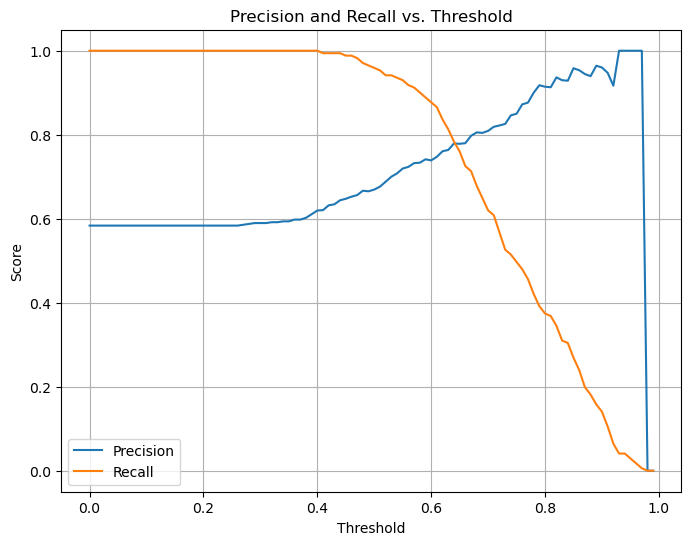

In [107]:
precision = []
recall = []

y_probs = model.predict_proba(X_val)[:, 1]

for t in threshold:
    pred = (y_probs >= t).astype(int)
    precision.append(precision_score(y_val, pred))
    recall.append(recall_score(y_val, pred))

plt.figure(figsize=(8, 6))
plt.plot(threshold, precision, label="Precision")
plt.plot(threshold, recall, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs. Threshold")
plt.legend()
plt.grid()
plt.show()

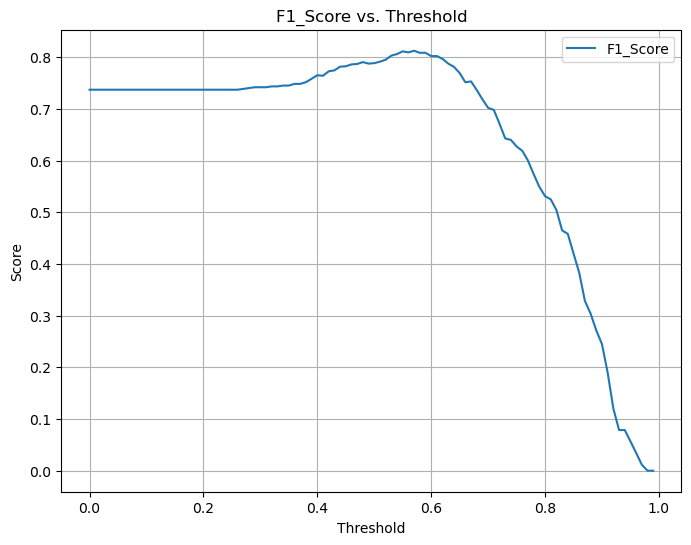

In [108]:
f1_scores = []

for t in threshold:
    pred = (y_probs >= t).astype(int)
    f1_scores.append(f1_score(y_val, pred, zero_division=0))


plt.figure(figsize=(8, 6))
plt.plot(threshold, f1_scores, label="F1_Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("F1_Score vs. Threshold")
plt.legend()
plt.grid()
plt.show()

In [110]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

In [111]:
train_idx, val_idx = next(kfold.split(df_full_train))

In [112]:
len(train_idx), len(val_idx)

(935, 234)

In [113]:
df_train = df_full_train.iloc[train_idx]
df_val = df_full_train.iloc[val_idx]

In [115]:
y_train = df_train.converted.values
y_val = df_val.converted.values

del df_train['converted']
del df_val['converted']

In [116]:
def model_train(data, y_train, C=1.0):
    dicts = data.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X = dv.fit_transform(dicts)
    
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X, y_train)

    return dv, model

In [117]:
def predict(df, dv, model):
    dicts = df.to_dict(orient='records')
    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]
    
    return y_pred

In [119]:
scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    del df_train['converted']
    del df_val['converted']

    dv, model = model_train(df_train, y_train)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)
    print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

0.806 +- 0.000
0.839 +- 0.033
0.818 +- 0.040
0.814 +- 0.035
0.822 +- 0.036


In [120]:
n_splits = 5
for C in [0.000001, 0.001, 1]:
    scores = []
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        del df_train['converted']
        del df_val['converted']

        dv, model = model_train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)
    print('%s %.3f +- %.4f' % (C, np.mean(scores), np.std(scores)))

1e-06 0.560 +- 0.0238
0.001 0.867 +- 0.0287
1 0.822 +- 0.0358
